# K-Means / DBSCAN Tuning

| | |
|---|---|
| **Algorithm** | KMeans, DBSCAN |
| **Dataset** | Iris (150 samples, 4 features) |
| **Task** | Clustering (비지도 학습) |
| **Metric** | Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Score |

## 튜닝 포인트

| # | 튜닝 | 내용 | 기대 효과 |
|---|---|---|---|
| 1 | **Feature Scaling** | StandardScaler 적용 | 스케일 차이가 유클리드 거리 왜곡 방지 |
| 2 | **n_init 증가** | 랜덤 초기화 횟수 ↑ | centroid 초기화 불안정성 감소 |
| 3 | **최적 k 탐색** | Elbow + 3가지 지표 동시 비교 | 신뢰성 있는 k 선택 |
| 4 | **DBSCAN eps 탐색** | k-distance graph | 데이터 기반 eps 결정 |

## Imports
---

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)

## Data Loading
---
- `iris.csv`: 150 samples, 4 features (SepalLength, SepalWidth, PetalLength, PetalWidth)
- 비지도 학습 → Id, Species 제외

In [13]:
df = pd.read_csv('../datasets/iris.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(150, 6)
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
X = df.drop(columns=['Id', 'Species']).values
feature_names = df.drop(columns=['Id', 'Species']).columns.tolist()

## Evaluation Metrics
---

| 지표 | 측정 기준 | 좋은 값 |
|---|---|---|
| Silhouette Score | 같은 클러스터 응집도 vs 다른 클러스터 분리도 | 1에 가까울수록 |
| Davies-Bouldin Index | 클러스터 간 유사도 평균 | 0에 가까울수록 |
| Calinski-Harabasz Score | 클러스터 간 분산 / 클러스터 내 분산 | 높을수록 |

In [15]:
def evaluate_clustering(X, labels, label=''):
    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    chi = calinski_harabasz_score(X, labels)
    print(f'{label:35s}  Silhouette: {sil:.4f}  DBI: {dbi:.4f}  CHI: {chi:.1f}')
    return sil, dbi, chi

## Base Model
---
- KMeans(n_clusters=3), 스케일링 없음, 기본 n_init=10

In [16]:
base_model = KMeans(n_clusters=3, random_state=42)
base_labels = base_model.fit_predict(X)
base_sil, base_dbi, base_chi = evaluate_clustering(X, base_labels, 'Base (no scaling)')

Base (no scaling)                    Silhouette: 0.5510  DBI: 0.6664  CHI: 560.4


## Tuning 1: Feature Scaling
---
- K-Means는 유클리드 거리로 가장 가까운 centroid를 찾는다
- Iris: SepalLength (4.3~7.9) vs PetalWidth (0.1~2.5) — 스케일 차이 존재
- 스케일이 큰 피처가 거리를 지배 → 실제 구조와 다른 클러스터 형성

In [17]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

sc_model = KMeans(n_clusters=3, random_state=42)
sc_labels = sc_model.fit_predict(X_sc)
sc_sil, sc_dbi, sc_chi = evaluate_clustering(X_sc, sc_labels, 'Scaled')

Scaled                               Silhouette: 0.4787  DBI: 0.7868  CHI: 156.1


## Tuning 2: n_init 증가
---
- K-Means는 centroid를 랜덤 초기화 → 매번 다른 결과 가능
- `n_init`: 다른 초기값으로 반복 실행 후 가장 낮은 inertia 선택
- 기본값 10 → 증가시킬수록 초기화 운에 따른 불안정성 감소

In [18]:
for n in [10, 20, 50]:
    m = KMeans(n_clusters=3, n_init=n, random_state=42)
    labels = m.fit_predict(X_sc)
    sil = silhouette_score(X_sc, labels)
    print(f'n_init={n:3d}  Silhouette: {sil:.4f}  Inertia: {m.inertia_:.2f}')

n_init= 10  Silhouette: 0.4590  Inertia: 140.97
n_init= 20  Silhouette: 0.4590  Inertia: 140.97
n_init= 50  Silhouette: 0.4590  Inertia: 140.97


## Tuning 3: 최적 k 탐색 — Elbow + 다중 지표
---
- 단일 지표만 보면 k 선택 신뢰도 낮음
- inertia (Elbow), Silhouette, Davies-Bouldin, Calinski-Harabasz 동시 비교
- 여러 지표가 일치하는 k를 선택

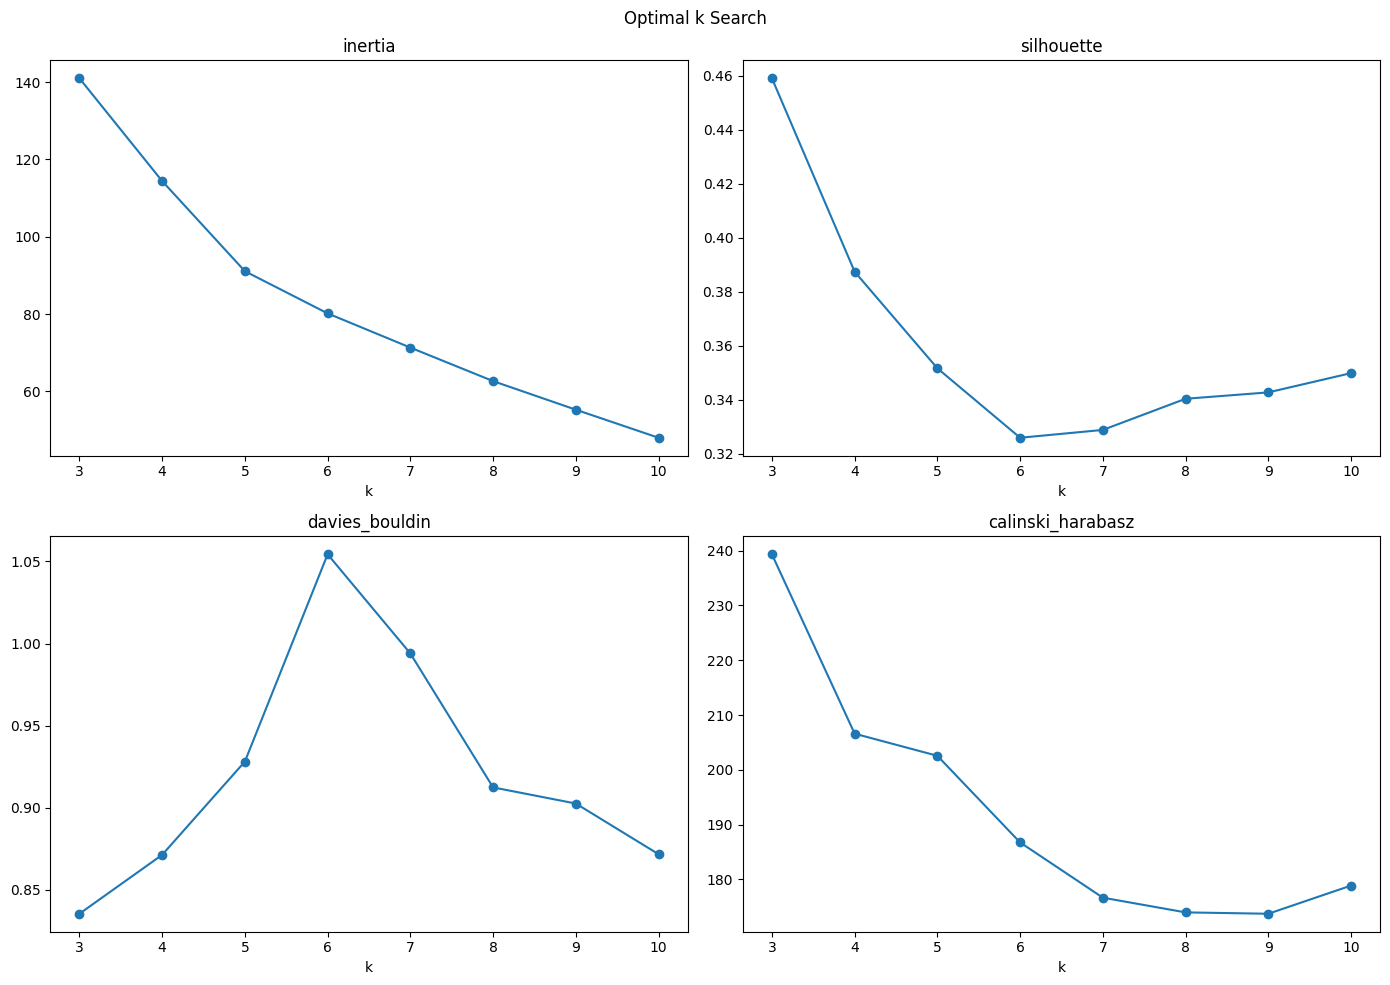

In [19]:
k_range = range(3, 11)
results_k = {'k': [], 'inertia': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}

for k in k_range:
    m = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = m.fit_predict(X_sc)
    results_k['k'].append(k)
    results_k['inertia'].append(m.inertia_)
    results_k['silhouette'].append(silhouette_score(X_sc, labels))
    results_k['davies_bouldin'].append(davies_bouldin_score(X_sc, labels))
    results_k['calinski_harabasz'].append(calinski_harabasz_score(X_sc, labels))

df_k = pd.DataFrame(results_k)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, ['inertia', 'silhouette', 'davies_bouldin', 'calinski_harabasz']):
    ax.plot(df_k['k'], df_k[col], marker='o')
    ax.set_xlabel('k')
    ax.set_title(col)
plt.suptitle('Optimal k Search')
plt.tight_layout()
plt.show()

## Tuning 4: DBSCAN — k-distance graph로 eps 탐색
---
- DBSCAN의 `eps`: 이웃으로 볼 반경
- k-distance graph: 각 샘플의 k번째 가장 가까운 이웃 거리를 정렬하여 시각화
- 급격히 꺾이는 지점(elbow)이 최적 eps 힌트 — 그 이전은 dense, 이후는 noise

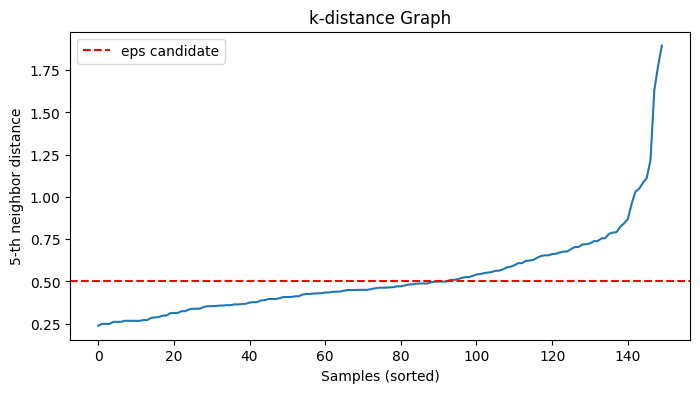

In [20]:
min_samples = 5
neigh = NearestNeighbors(n_neighbors=min_samples)
neigh.fit(X_sc)
distances, _ = neigh.kneighbors(X_sc)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.xlabel('Samples (sorted)')
plt.ylabel(f'{min_samples}-th neighbor distance')
plt.title('k-distance Graph')
plt.axhline(y=0.5, color='r', linestyle='--', label='eps candidate')
plt.legend()
plt.show()

In [21]:
for eps in [0.3, 0.5, 0.7, 1.0]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_sc)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = np.sum(labels == -1)
    if n_clusters >= 2:
        sil = silhouette_score(X_sc, labels)
        print(f'eps={eps}  clusters={n_clusters}  noise={n_noise}  Silhouette={sil:.4f}')
    else:
        print(f'eps={eps}  clusters={n_clusters}  noise={n_noise}  (skip — not enough clusters)')

eps=0.3  clusters=3  noise=120  Silhouette=-0.1927
eps=0.5  clusters=2  noise=35  Silhouette=0.3492
eps=0.7  clusters=2  noise=8  Silhouette=0.5192
eps=1.0  clusters=2  noise=3  Silhouette=0.5371


## Results (K-Means)
---
- Silhouette 기준 최적 k 선택 후 Base와 비교

Best k=3 + Scaled                    Silhouette: 0.4590  DBI: 0.8354  CHI: 239.3
                 Model  Silhouette  Davies-Bouldin  Calinski-Harabasz
Base (no scaling, k=3)    0.550964        0.666391         560.366004
          Scaled (k=3)    0.478724        0.786801         156.143038
     Best k=3 + Scaled    0.458972        0.835410         239.341801


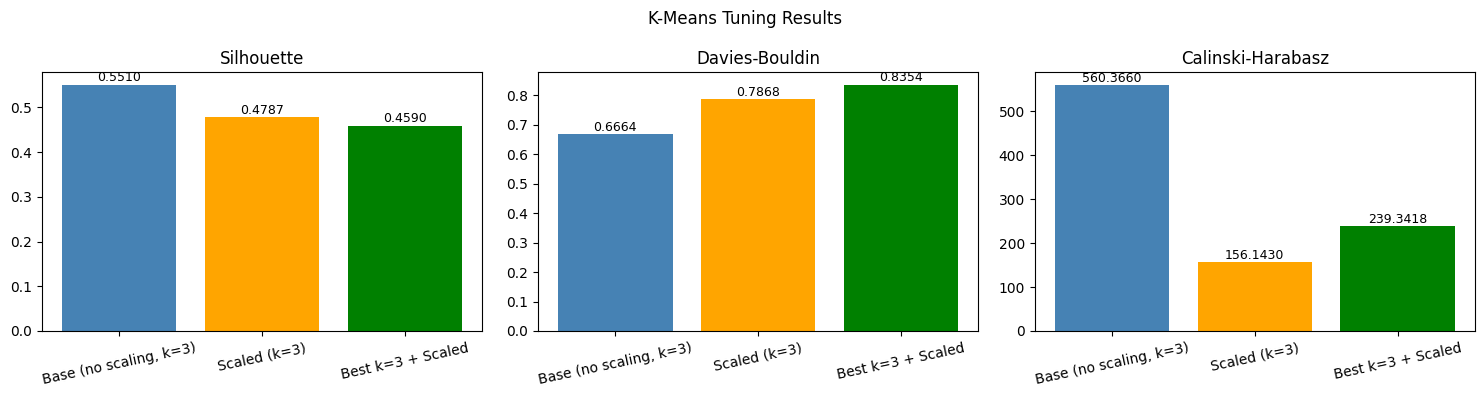

In [22]:
best_k = int(df_k.loc[df_k['silhouette'].idxmax(), 'k'])
best_model = KMeans(n_clusters=best_k, n_init=20, random_state=42)
best_labels = best_model.fit_predict(X_sc)
best_sil, best_dbi, best_chi = evaluate_clustering(X_sc, best_labels, f'Best k={best_k} + Scaled')

result_table = pd.DataFrame({
    'Model':              ['Base (no scaling, k=3)', 'Scaled (k=3)', f'Best k={best_k} + Scaled'],
    'Silhouette':         [base_sil, sc_sil, best_sil],
    'Davies-Bouldin':     [base_dbi, sc_dbi, best_dbi],
    'Calinski-Harabasz':  [base_chi, sc_chi, best_chi]
})
print(result_table.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']):
    bars = ax.bar(result_table['Model'], result_table[col], color=['steelblue', 'orange', 'green'])
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=12)
    for bar, val in zip(bars, result_table[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('K-Means Tuning Results')
plt.tight_layout()
plt.show()